In [73]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [74]:
classFile =r"D:\Opencv oct-Nov\15_V4\coco_class_labels.txt"
modelFile=r"D:\Opencv oct-Nov\15_V4\ssd_mobilenet_frozen_inference_graph.pb"
configFile =r"D:\Opencv oct-Nov\15_V4\ssd_mobilenet_v2_coco_2018_03_29.pbtxt"


In [75]:
import requests
from os import path

if(not path.exists(modelFile)):
    print('Downloading MobileNet SSD Model.......')
    
    url = 'https://opencv-courses.s3.us-west-2.amazonaws.com/ssd_mobilenet_frozen_inference_graph.pb'

    r = requests.get(url)

    with open(modelFile, 'wb') as f:
        f.write(r.content)

    print('ssd_mobilenet_frozen_inference_graph Download complete!')

In [76]:
net=cv2.dnn.readNetFromTensorflow(modelFile,configFile)

In [77]:
with open (classFile) as fp:
    labels=fp.read().split('\n')
print(sorted(labels))

['', 'airplane', 'apple', 'backpack', 'banana', 'baseball bat', 'baseball glove', 'bear', 'bed', 'bench', 'bicycle', 'bird', 'blender', 'boat', 'book', 'bottle', 'bowl', 'broccoli', 'bus', 'cake', 'car', 'carrot', 'cat', 'cell phone', 'chair', 'clock', 'couch', 'cow', 'cup', 'desk', 'dining table', 'dog', 'donut', 'door', 'elephant', 'eye glasses', 'fire hydrant', 'fork', 'frisbee', 'giraffe', 'hair brush', 'hair drier', 'handbag', 'hat', 'horse', 'hot dog', 'keyboard', 'kite', 'knife', 'laptop', 'microwave', 'mirror', 'motorcycle', 'mouse', 'orange', 'oven', 'parking meter', 'person', 'pizza', 'plate', 'potted plant', 'refrigerator', 'remote', 'sandwich', 'scissors', 'sheep', 'shoe', 'sink', 'skateboard', 'skis', 'snowboard', 'spoon', 'sports ball', 'stop sign', 'street sign', 'suitcase', 'surfboard', 'teddy bear', 'tennis racket', 'tie', 'toaster', 'toilet', 'toothbrush', 'traffic light', 'train', 'truck', 'tv', 'umbrella', 'unlabeled', 'vase', 'window', 'wine glass', 'zebra']


In [78]:
def detect_objects(net,img):
    dim=300
    mean=(0,0,0)
    blob=cv2.dnn.blobFromImage(img,1.0,(dim,dim),mean,True)
    net.setInput(blob)
    objects=net.forward()
    return objects
    

In [79]:
Img=r"D:\Opencv oct-Nov\15_V4\fruit-vegetable.jpg"
food_img =cv2.imread(Img)
food_objects=detect_objects(net,food_img)
first_detected_obj=food_objects[0][0][0]
print(food_objects)
print(first_detected_obj)

[[[[ 0.00000000e+00  5.70000000e+01  8.88634622e-01  6.57617092e-01
     3.31570625e-01  8.07159185e-01  9.16203260e-01]
   [ 0.00000000e+00  5.70000000e+01  8.70576859e-01  6.95723772e-01
     3.04736257e-01  8.44052076e-01  8.46372843e-01]
   [ 0.00000000e+00  5.20000000e+01  8.37999344e-01  1.53683797e-01
     1.19670928e-02  4.88869548e-01  5.57175994e-01]
   [ 0.00000000e+00  5.70000000e+01  8.13953340e-01  7.38126636e-01
     3.06167096e-01  9.03744698e-01  7.79480815e-01]
   [ 0.00000000e+00  5.30000000e+01  7.47386932e-01  7.58427382e-03
     4.01439339e-01  6.18733704e-01  9.80455995e-01]
   [ 0.00000000e+00  5.30000000e+01  7.15499461e-01  5.08544326e-01
     8.22290719e-01  7.73512840e-01  9.96295154e-01]
   [ 0.00000000e+00  5.70000000e+01  7.09190011e-01  5.97260118e-01
     2.85867870e-01  7.71396279e-01  9.01321948e-01]
   [ 0.00000000e+00  5.30000000e+01  5.76824069e-01  3.78561020e-03
     6.52702212e-01  1.64824456e-01  1.00570917e+00]
   [ 0.00000000e+00  5.30000000e

In [80]:
def draw_text(im,text,x,y):
    fontface=cv2.FONT_HERSHEY_SIMPLEX
    font_scale=0.7
    thickness=1
    textSize=cv2.getTextSize(text,fontface,font_scale,thickness)
    dim=textSize[0]
    baseline=textSize[1]
    cv2.rectangle(im,
              (x, y),
              (x + dim[0], y + dim[1] + baseline),
              (0, 0, 0),
              cv2.FILLED)
    cv2.putText(
    im,
    text,
    (x, y + dim[1]),
    fontface,
    font_scale,
    (0,255,225),   # color
    thickness,     # thickness
    cv2.LINE_AA
)
    
    

In [81]:
def draw_objects(im, objects, threshold = 0.25):
    """Displays a box and text for each detected object exceeding the confidence threshold."""
    rows = im.shape[0]
    cols = im.shape[1]

    # For every detected object.
    for i in range(objects.shape[2]):
        # Find the class and confidence.
        classId = int(objects[0, 0, i, 1])
        score = float(objects[0, 0, i, 2])
        
        # Recover original cordinates from normalized coordinates
        x = int(objects[0, 0, i, 3] * cols)
        y = int(objects[0, 0, i, 4] * rows)
        w = int(objects[0, 0, i, 5] * cols - x)
        h = int(objects[0, 0, i, 6] * rows - y)
        # Check if the detection is of good quality
        if score > threshold:
            draw_text(im, "{}".format(labels[classId]), x, y)
            cv2.rectangle(im, (x, y), (x + w, y + h), (255, 255, 255), 2)
    
    # Convert Image to RGB since we are using Matplotlib for displaying image.
    mp_img = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    return mp_img

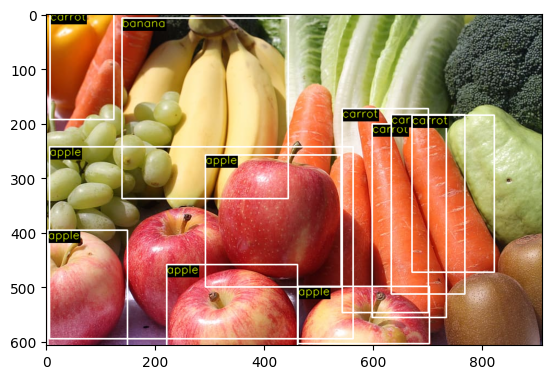

In [82]:
result=draw_objects(food_img.copy(),food_objects,0.4)
plt.imshow(result)

In [83]:
ig=r"D:\Opencv oct-Nov\colourful-vegetables-and-fruits.jpg"
img2=cv2.imread(ig)

food_objects1=detect_objects(net,img2)

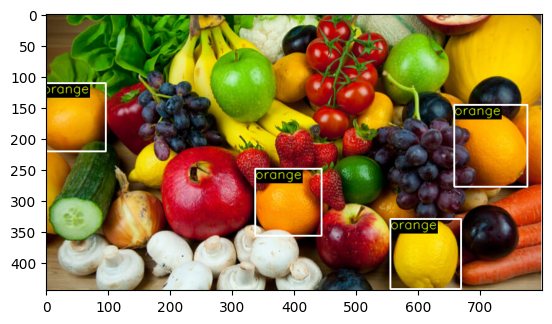

In [84]:
result1=draw_objects(img2.copy(),food_objects1,0.4)
plt.imshow(result1)

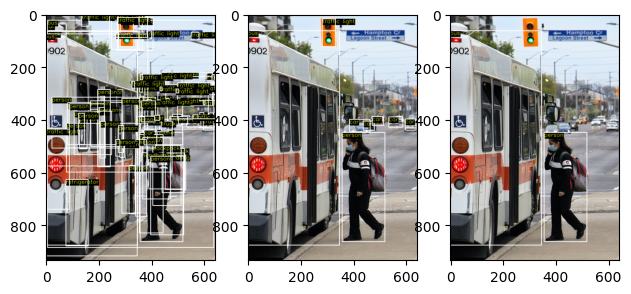

In [89]:
tf=r"D:\Opencv oct-Nov\15_V4\traffic.jpg"
traffic=cv2.imread(tf)

traffic_objects=detect_objects(net,traffic)
low=draw_objects(traffic.copy(),traffic_objects,0.0)
med=draw_objects(traffic.copy(),traffic_objects,0.4)
high=draw_objects(traffic.copy(),traffic_objects,0.9)

plt.figure(figsize=[10,5])
plt.subplot(141);plt.imshow(low)
plt.subplot(142);plt.imshow(med)
plt.subplot(143);plt.imshow(high)